# NASA GISS Surface Temperature Analysis
### Global Temperature Anomalies 1880–2026 using Python and pandas

**Author:** Emma Follis  
**Data source:** [NASA GISS Surface Temperature Analysis (GISTEMP v4)](https://data.giss.nasa.gov/gistemp/)  
**Last updated:** June 2026

---

## Overview
This notebook analyzes NASA's GISS Surface Temperature dataset — one of the most cited
climate records in the world. The dataset tracks global surface temperature anomalies
relative to a 1951–1980 baseline, covering 1880 to present. A positive anomaly means
that year was warmer than the baseline average; a negative anomaly means cooler.

The analysis focuses on four questions:
1. How has global temperature changed since 1880?
2. Which years and decades were the warmest on record?
3. How has the rate of warming changed over time?
4. How do individual months compare across the full record?

## Setup
### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats

print("Libraries imported successfully")

Libraries imported successfully


### Loading and cleaning the data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving GLB.Ts+dSST.csv to GLB.Ts+dSST.csv


In [3]:
# Load the CSV — this file has a specific structure that needs special handling
df_raw = pd.read_csv('GLB.Ts+dSST.csv', skiprows=1)

# Preview the raw data before cleaning
print("Raw data shape:", df_raw.shape)
print("\nFirst 5 rows:")
print(df_raw.head())
print("\nColumn names:")
print(df_raw.columns.tolist())

Raw data shape: (147, 19)

First 5 rows:
   Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
0  1880 -0.19 -0.25 -0.10 -0.17 -0.10  -.22  -.19  -.11  -.15  -.24  -.23   
1  1881 -0.20 -0.16  0.02  0.04  0.06  -.19   .01  -.04  -.16  -.22  -.19   
2  1882  0.15  0.13  0.04 -0.16 -0.14  -.23  -.17  -.08  -.15  -.24  -.17   
3  1883 -0.30 -0.37 -0.13 -0.18 -0.18  -.07  -.08  -.14  -.22  -.11  -.24   
4  1884 -0.13 -0.08 -0.37 -0.40 -0.34  -.35  -.31  -.28  -.27  -.25  -.34   

    Dec   J-D   D-N   DJF   MAM   JJA   SON  
0  -.19  -.18   ***   *** -0.12  -.17  -.21  
1  -.07  -.09  -.10  -.18  0.04  -.07  -.19  
2  -.37  -.11  -.09   .07 -0.09  -.16  -.19  
3  -.12  -.18  -.20  -.34 -0.16  -.10  -.19  
4  -.31  -.29  -.27  -.11 -0.37  -.31  -.29  

Column names:
['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON']


### Data cleaning
The raw GISS file contains missing value markers (***), inconsistent
number formatting, and a footer row that needs to be removed before analysis.

In [4]:
# Replace *** with NaN (pandas standard for missing values)
df = df_raw.replace('***', float('nan'))

# Replace any other non-numeric placeholders
df = df.replace('****', float('nan'))

# Convert all columns except Year to numeric
# errors='coerce' turns anything that can't be converted into NaN
cols_to_convert = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec',
                   'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON']

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert Year to integer
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Drop any rows where Year is NaN (catches footer rows)
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

# Drop the last row if it's a footer
df = df[df['Year'] <= 2026]

# Check the result
print("Cleaned data shape:", df.shape)
print(f"\nYear range: {df['Year'].min()} to {df['Year'].max()}")
print(f"\nMissing values in J-D (annual average): {df['J-D'].isna().sum()}")
print(f"\nFirst 5 rows after cleaning:")
print(df[['Year', 'Jan', 'Jun', 'J-D']].head())
print(f"\nLast 5 rows after cleaning:")
print(df[['Year', 'Jan', 'Jun', 'J-D']].tail())

Cleaned data shape: (147, 19)

Year range: 1880 to 2026

Missing values in J-D (annual average): 1

First 5 rows after cleaning:
   Year   Jan   Jun   J-D
0  1880 -0.19 -0.22 -0.18
1  1881 -0.20 -0.19 -0.09
2  1882  0.15 -0.23 -0.11
3  1883 -0.30 -0.07 -0.18
4  1884 -0.13 -0.35 -0.29

Last 5 rows after cleaning:
     Year   Jan   Jun   J-D
142  2022  0.91  0.92  0.89
143  2023  0.88  1.08  1.17
144  2024  1.25  1.24  1.28
145  2025  1.38  1.07  1.19
146  2026  1.08   NaN   NaN


### Data exploration
Understanding the distribution of temperature anomalies before visualization.

In [5]:
# Work with complete years only (drop 2026 for annual analysis)
df_complete = df.dropna(subset=['J-D']).copy()

print("=== ANNUAL TEMPERATURE ANOMALY SUMMARY ===")
print(f"\nTotal complete years: {len(df_complete)}")
print(f"\nOverall statistics (°C anomaly relative to 1951-1980 baseline):")
print(df_complete['J-D'].describe().round(3))

print(f"\n=== TOP 10 WARMEST YEARS ===")
warmest = df_complete.nlargest(10, 'J-D')[['Year', 'J-D']].reset_index(drop=True)
warmest.index += 1
print(warmest.to_string())

print(f"\n=== TOP 10 COLDEST YEARS ===")
coldest = df_complete.nsmallest(10, 'J-D')[['Year', 'J-D']].reset_index(drop=True)
coldest.index += 1
print(coldest.to_string())

print(f"\n=== DECADE AVERAGES ===")
df_complete['Decade'] = (df_complete['Year'] // 10) * 10
decade_avg = df_complete.groupby('Decade')['J-D'].mean().round(3)
print(decade_avg.to_string())

=== ANNUAL TEMPERATURE ANOMALY SUMMARY ===

Total complete years: 146

Overall statistics (°C anomaly relative to 1951-1980 baseline):
count    146.000
mean       0.082
std        0.402
min       -0.490
25%       -0.200
50%       -0.030
75%        0.318
max        1.280
Name: J-D, dtype: float64

=== TOP 10 WARMEST YEARS ===
    Year   J-D
1   2024  1.28
2   2025  1.19
3   2023  1.17
4   2016  1.01
5   2020  1.01
6   2019  0.98
7   2017  0.92
8   2015  0.90
9   2022  0.89
10  2018  0.85

=== TOP 10 COLDEST YEARS ===
    Year   J-D
1   1909 -0.49
2   1904 -0.48
3   1917 -0.46
4   1911 -0.45
5   1910 -0.44
6   1908 -0.43
7   1907 -0.39
8   1903 -0.37
9   1912 -0.37
10  1916 -0.37

=== DECADE AVERAGES ===
Decade
1880   -0.216
1890   -0.241
1900   -0.317
1910   -0.333
1920   -0.240
1930   -0.123
1940    0.042
1950   -0.047
1960   -0.031
1970    0.035
1980    0.247
1990    0.387
2000    0.589
2010    0.808
2020    1.065


## Visualization 1: The Full Temperature Record
### Global temperature anomalies from 1880 to 2025
The most important chart in this analysis — 146 years of global surface
temperature change relative to the 1951-1980 baseline.

Temperature trend: 0.0832°C per decade
R² value: 0.7667
P-value: 2.35e-47


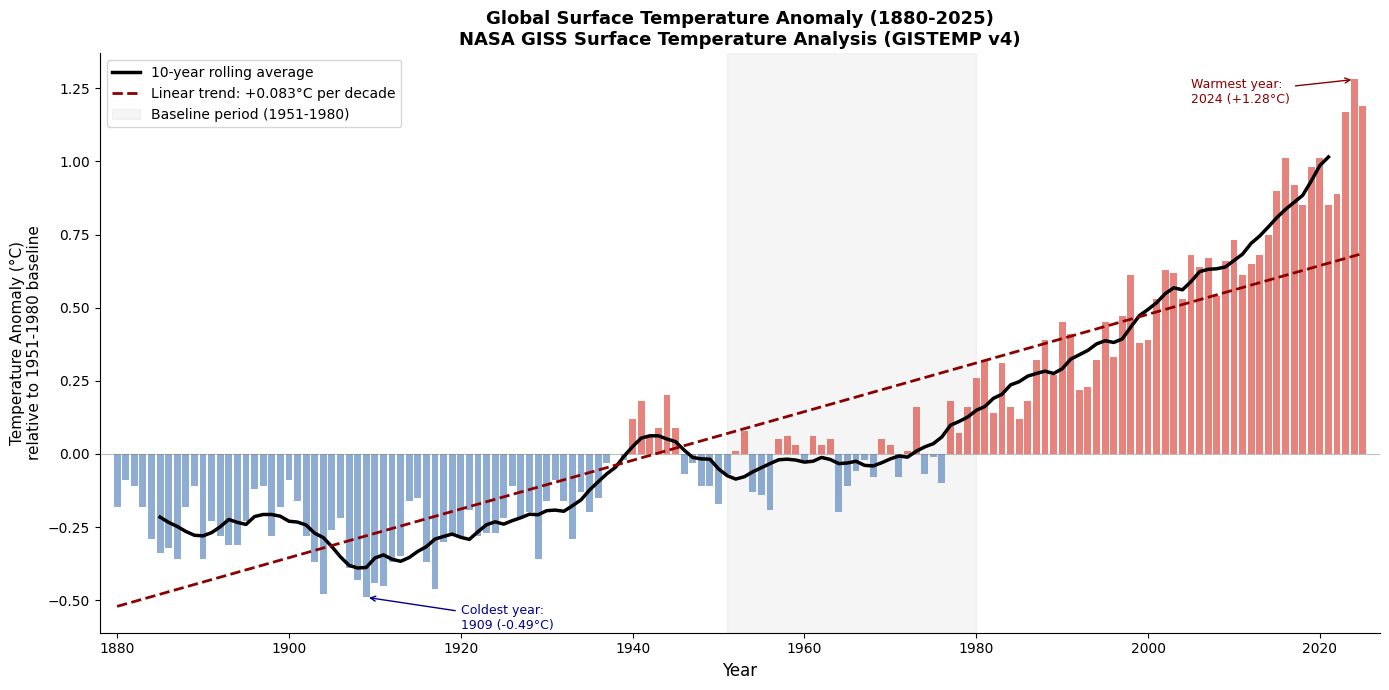

Chart saved as temperature_record.png


In [8]:
# Calculate 10-year rolling average for trend line
df_complete['rolling_10yr'] = df_complete['J-D'].rolling(window=10, center=True).mean()

# Linear regression for overall trend line
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_complete['Year'], df_complete['J-D']
)
trend_line = slope * df_complete['Year'] + intercept

print(f"Temperature trend: {slope*10:.4f}°C per decade")
print(f"R² value: {r_value**2:.4f}")
print(f"P-value: {p_value:.2e}")

# Create the chart
fig, ax = plt.subplots(figsize=(14, 7))

# Color bars by whether they are above or below zero
colors = ['#d73027' if val > 0 else '#4575b4' for val in df_complete['J-D']]

# Plot annual anomaly bars
ax.bar(df_complete['Year'], df_complete['J-D'],
       color=colors, alpha=0.6, width=0.8, zorder=2)

# Plot 10-year rolling average
ax.plot(df_complete['Year'], df_complete['rolling_10yr'],
        color='black', linewidth=2.5, zorder=3, label='10-year rolling average')

# Plot linear trend line
ax.plot(df_complete['Year'], trend_line,
        color='darkred', linewidth=2, linestyle='--', zorder=3,
        label=f'Linear trend: +{slope*10:.3f}°C per decade')

# Zero baseline reference line
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='-', alpha=0.5)

# Shade the baseline period
ax.axvspan(1951, 1980, alpha=0.08, color='gray', label='Baseline period (1951-1980)')

# Annotations
ax.annotate(f'Warmest year:\n2024 (+1.28°C)',
            xy=(2024, 1.28), xytext=(2005, 1.20),
            fontsize=9, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1))

ax.annotate(f'Coldest year:\n1909 (-0.49°C)',
            xy=(1909, -0.49), xytext=(1920, -0.60),
            fontsize=9, color='darkblue',
            arrowprops=dict(arrowstyle='->', color='darkblue', lw=1))

# Labels and formatting
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature Anomaly (°C)\nrelative to 1951-1980 baseline', fontsize=11)
ax.set_title('Global Surface Temperature Anomaly (1880-2025)\nNASA GISS Surface Temperature Analysis (GISTEMP v4)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(1878, 2027)
sns.despine()

plt.tight_layout()
plt.savefig('temperature_record.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as temperature_record.png")

## Visualization 2: Decade-by-Decade Warming
### How the average temperature has shifted each decade since 1880
The decade averages reveal not just that warming is happening,
but that the rate of warming is itself accelerating.

Decade statistics:
 Decade  avg_anomaly  std_dev  years  change_from_prev
   1880       -0.216    0.103     10               NaN
   1890       -0.241    0.083     10            -0.025
   1900       -0.317    0.136     10            -0.076
   1910       -0.333    0.111     10            -0.016
   1920       -0.240    0.068     10             0.093
   1930       -0.123    0.090     10             0.117
   1940        0.042    0.115     10             0.165
   1950       -0.047    0.104     10            -0.089
   1960       -0.031    0.084     10             0.016
   1970        0.035    0.105     10             0.066
   1980        0.247    0.092     10             0.212
   1990        0.387    0.118     10             0.140
   2000        0.589    0.091     10             0.202
   2010        0.808    0.143     10             0.219
   2020        1.065    0.175      6             0.257


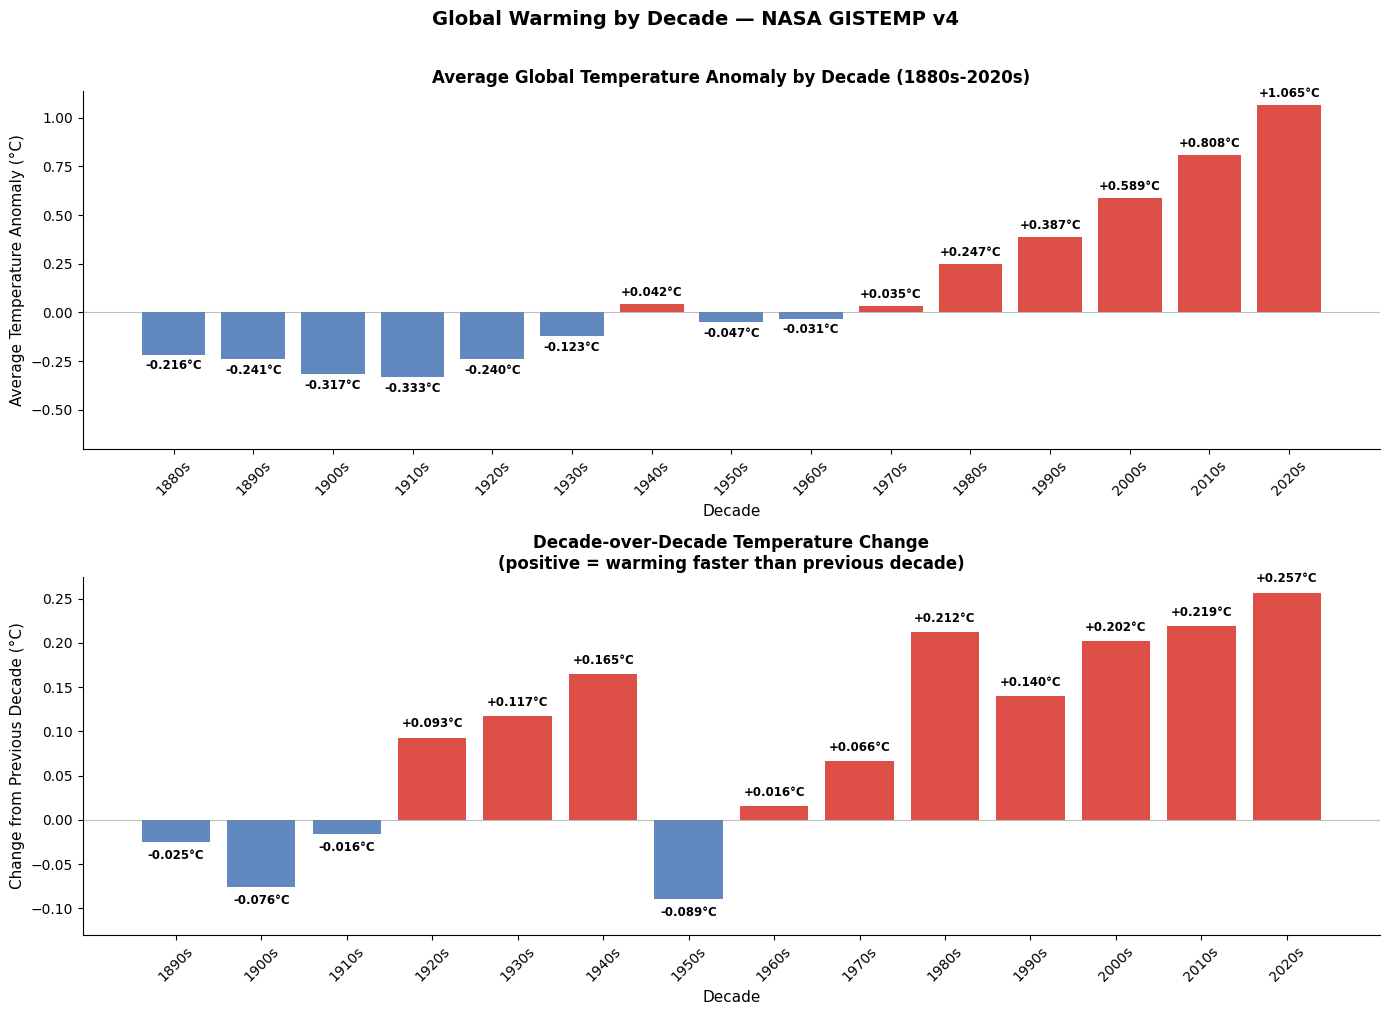

Chart saved as decade_warming.png


In [15]:
# Calculate decade averages and the change between each decade
decade_stats = df_complete.groupby('Decade')['J-D'].agg(['mean', 'std', 'count']).round(3)
decade_stats.columns = ['avg_anomaly', 'std_dev', 'years']
decade_stats = decade_stats.reset_index()

# Calculate decade-over-decade change
decade_stats['change_from_prev'] = decade_stats['avg_anomaly'].diff().round(3)

print("Decade statistics:")
print(decade_stats.to_string(index=False))

# Create the chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# --- Top chart: Decade average anomalies ---
colors_decade = ['#d73027' if val > 0 else '#4575b4'
                 for val in decade_stats['avg_anomaly']]

bars = ax1.bar(decade_stats['Decade'], decade_stats['avg_anomaly'],
               color=colors_decade, width=8, alpha=0.85, zorder=2)

# Add value labels on each bar
for bar, val in zip(bars, decade_stats['avg_anomaly']):
    ypos = val + 0.025 if val >= 0 else val - 0.025
    va = 'bottom' if val >= 0 else 'top'
    ax1.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:+.3f}°C', ha='center', va=va, fontsize=8.5,
             fontweight='bold')

ax1.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
ax1.set_xlabel('Decade', fontsize=11)
ax1.set_ylabel('Average Temperature Anomaly (°C)', fontsize=11)
ax1.set_title('Average Global Temperature Anomaly by Decade (1880s-2020s)',
              fontsize=12, fontweight='bold')
ax1.set_xticks(decade_stats['Decade'])
ax1.set_xticklabels([f"{d}s" for d in decade_stats['Decade']], rotation=45)
ax1.set_ylim(bottom=-0.70)
sns.despine(ax=ax1)

# --- Bottom chart: Decade-over-decade change ---
change_data = decade_stats.dropna(subset=['change_from_prev'])
colors_change = ['#d73027' if val > 0 else '#4575b4'
                 for val in change_data['change_from_prev']]

bars2 = ax2.bar(change_data['Decade'], change_data['change_from_prev'],
                color=colors_change, width=8, alpha=0.85, zorder=2)

# Add value labels
for bar, val in zip(bars2, change_data['change_from_prev']):
    ypos = val + 0.008 if val >= 0 else val - 0.008
    va = 'bottom' if val >= 0 else 'top'
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:+.3f}°C', ha='center', va=va, fontsize=8.5,
             fontweight='bold')

ax2.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Decade', fontsize=11)
ax2.set_ylabel('Change from Previous Decade (°C)', fontsize=11)
ax2.set_title('Decade-over-Decade Temperature Change\n(positive = warming faster than previous decade)',
              fontsize=12, fontweight='bold')
ax2.set_xticks(change_data['Decade'])
ax2.set_xticklabels([f"{d}s" for d in change_data['Decade']], rotation=45)
ax2.set_ylim(bottom=-0.13)
sns.despine(ax=ax2)

plt.suptitle('Global Warming by Decade — NASA GISTEMP v4',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('decade_warming.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as decade_warming.png")

## Visualization 3: Seasonal and Monthly Breakdown
### Are all months warming equally, or are some seasons changing faster?
Breaking the annual average down by month and season reveals
which parts of the year are driving the overall warming trend.

Average monthly anomaly — Early period (1880-1980):
Jan   -0.160
Feb   -0.155
Mar   -0.147
Apr   -0.151
May   -0.152
Jun   -0.168
Jul   -0.133
Aug   -0.141
Sep   -0.132
Oct   -0.106
Nov   -0.118
Dec   -0.151

Average monthly anomaly — Recent period (1981-2025):
Jan    0.610
Feb    0.627
Mar    0.668
Apr    0.590
May    0.555
Jun    0.550
Jul    0.551
Aug    0.569
Sep    0.568
Oct    0.590
Nov    0.590
Dec    0.577

Difference (recent minus early):
Jan    0.770
Feb    0.782
Mar    0.815
Apr    0.741
May    0.707
Jun    0.718
Jul    0.684
Aug    0.710
Sep    0.700
Oct    0.696
Nov    0.708
Dec    0.728


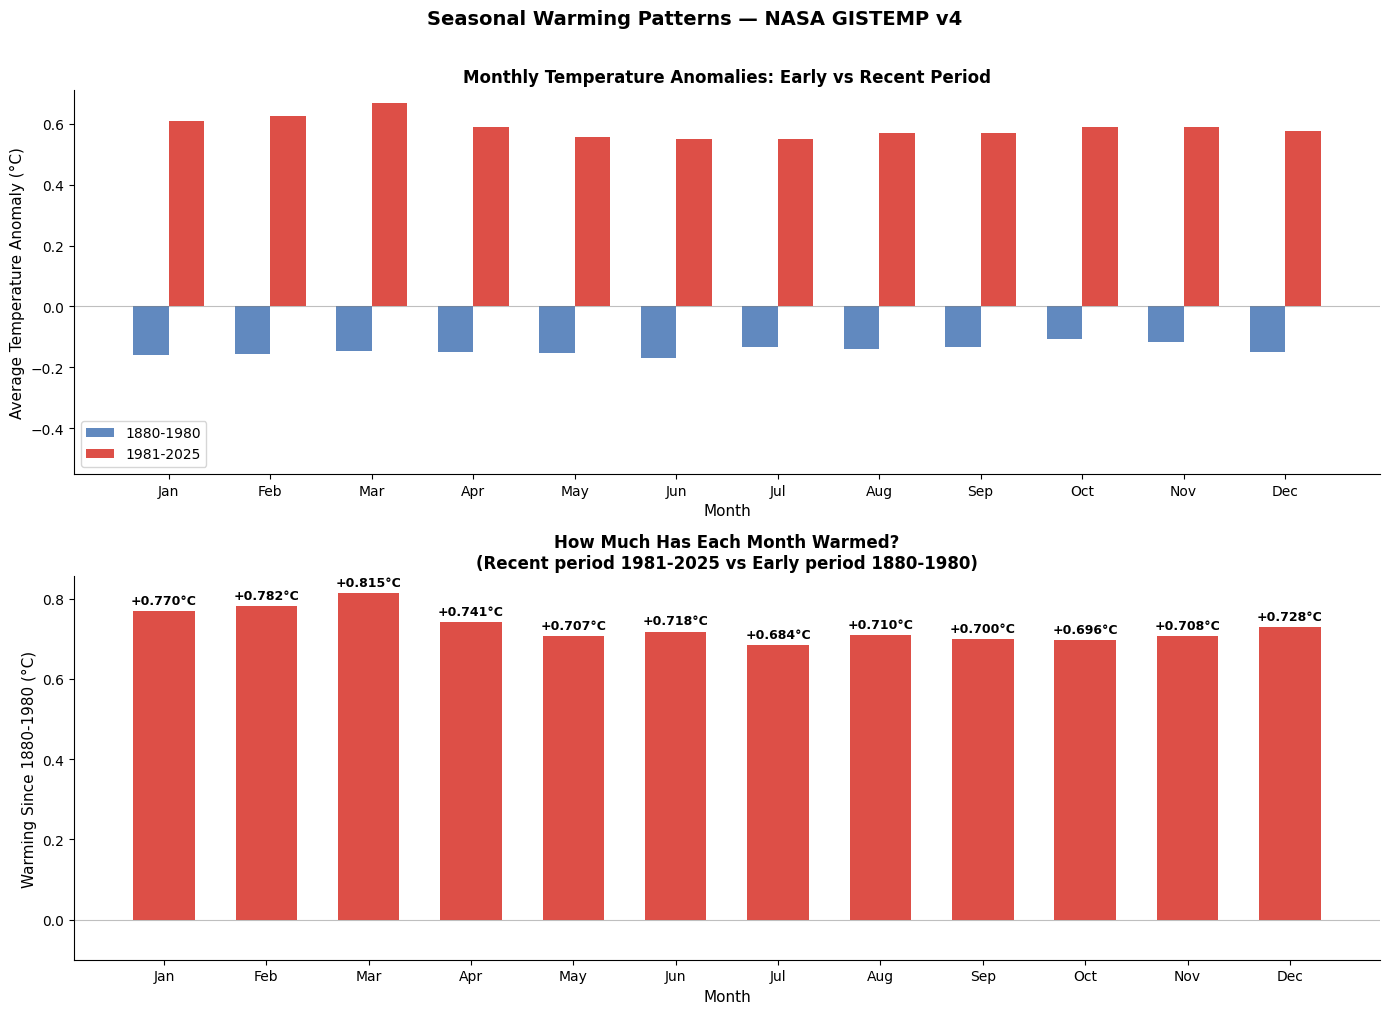

Chart saved as seasonal_breakdown.png


In [16]:
# Calculate average anomaly by month across two periods
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Split into early and recent periods
early = df_complete[df_complete['Year'] <= 1980]
recent = df_complete[df_complete['Year'] > 1980]

early_monthly = early[months].mean().round(3)
recent_monthly = recent[months].mean().round(3)
difference = (recent_monthly - early_monthly).round(3)

print("Average monthly anomaly — Early period (1880-1980):")
print(early_monthly.to_string())
print("\nAverage monthly anomaly — Recent period (1981-2025):")
print(recent_monthly.to_string())
print("\nDifference (recent minus early):")
print(difference.to_string())

# Create the chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

x = range(len(months))
width = 0.35

# --- Top chart: Monthly averages comparison ---
bars1 = ax1.bar([i - width/2 for i in x], early_monthly.values,
                width=width, color='#4575b4', alpha=0.85, label='1880-1980')
bars2 = ax1.bar([i + width/2 for i in x], recent_monthly.values,
                width=width, color='#d73027', alpha=0.85, label='1981-2025')

ax1.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
ax1.set_xticks(list(x))
ax1.set_xticklabels(months)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Average Temperature Anomaly (°C)', fontsize=11)
ax1.set_title('Monthly Temperature Anomalies: Early vs Recent Period',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_ylim(bottom=-0.55)
sns.despine(ax=ax1)

# --- Bottom chart: Difference between periods ---
colors_diff = ['#d73027' if val > 0 else '#4575b4' for val in difference.values]
bars3 = ax2.bar(list(x), difference.values, color=colors_diff, alpha=0.85, width=0.6)

# Add value labels
for bar, val in zip(bars3, difference.values):
    ypos = val + 0.01 if val >= 0 else val - 0.01
    va = 'bottom' if val >= 0 else 'top'
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:+.3f}°C', ha='center', va=va, fontsize=9,
             fontweight='bold')

ax2.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
ax2.set_xticks(list(x))
ax2.set_xticklabels(months)
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Warming Since 1880-1980 (°C)', fontsize=11)
ax2.set_title('How Much Has Each Month Warmed?\n(Recent period 1981-2025 vs Early period 1880-1980)',
              fontsize=12, fontweight='bold')
ax2.set_ylim(bottom=-0.10)
sns.despine(ax=ax2)

plt.suptitle('Seasonal Warming Patterns — NASA GISTEMP v4',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('seasonal_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as seasonal_breakdown.png")

## Visualization 4: Monthly Temperature Heatmap
### Every month of every year since 1880 — the complete picture
A heatmap showing all 146 years × 12 months of temperature anomaly data
in one visualization. Each cell is one month of one year, colored by
how warm or cool it was relative to the 1951-1980 baseline.

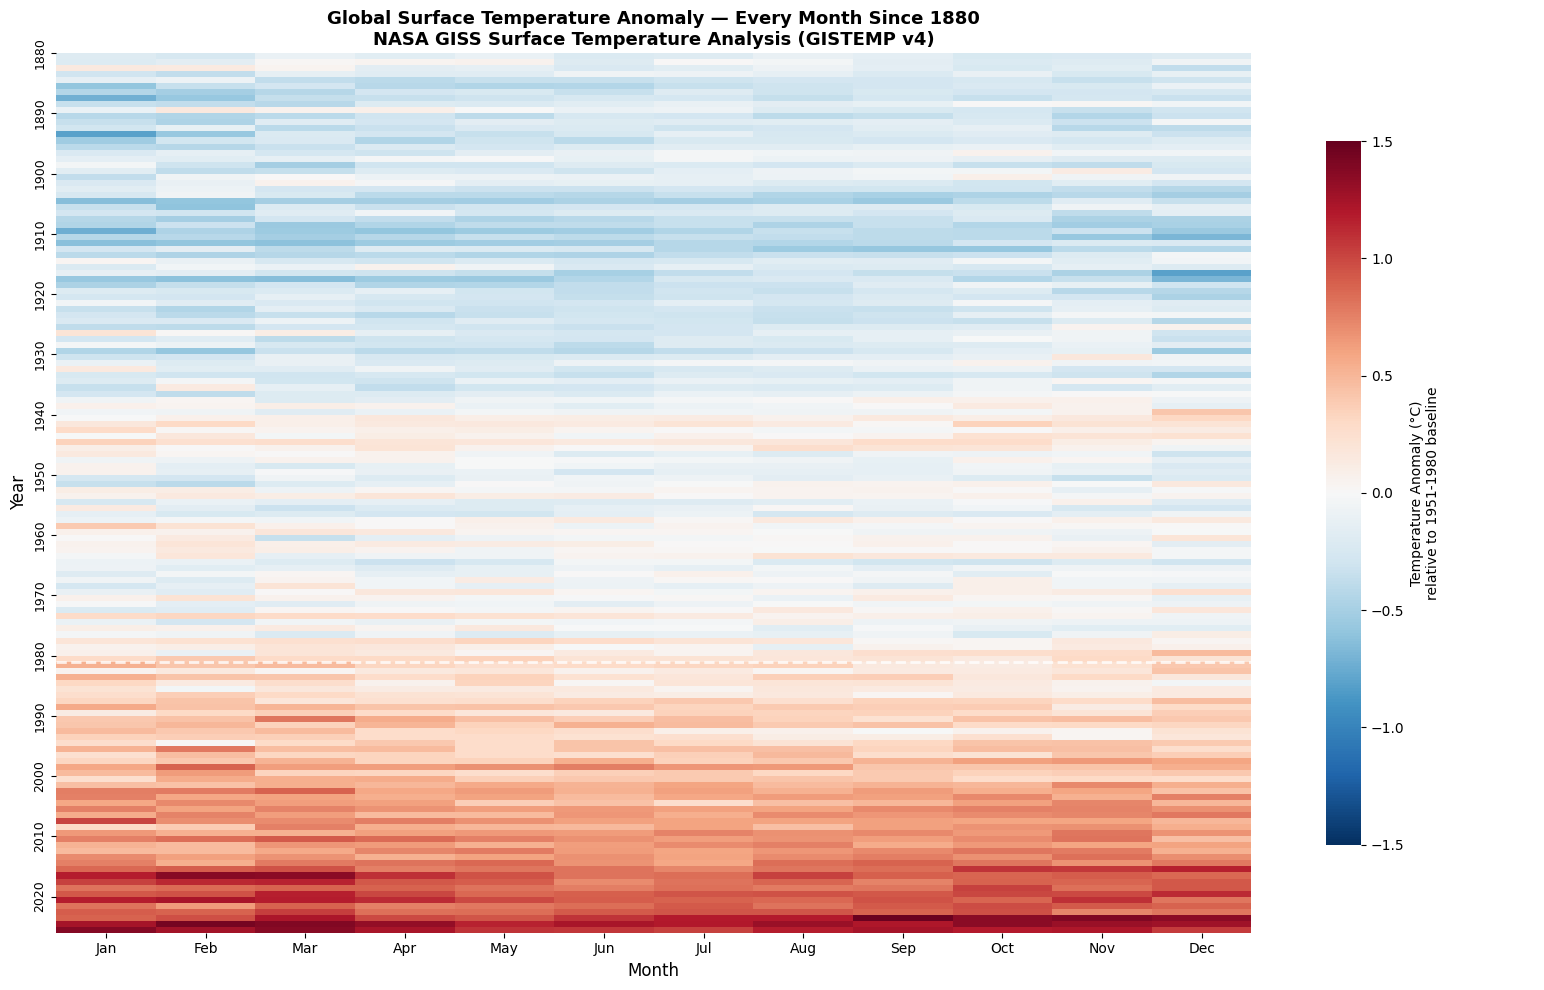

Chart saved as monthly_heatmap.png


In [17]:
# Build a matrix of monthly anomalies — years as rows, months as columns
heatmap_data = df_complete[['Year'] + months].set_index('Year')

# Create the heatmap
fig, ax = plt.subplots(figsize=(16, 10))

# Use a diverging colormap centered on zero
sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    center=0,
    vmin=-1.5,
    vmax=1.5,
    ax=ax,
    cbar_kws={
        'label': 'Temperature Anomaly (°C)\nrelative to 1951-1980 baseline',
        'shrink': 0.8
    },
    linewidths=0,
    xticklabels=True,
    yticklabels=10
)

# Add a horizontal line at the start of the recent period
ax.axhline(y=df_complete[df_complete['Year'] == 1981].index[0] -
           df_complete.index[0],
           color='white', linewidth=2, linestyle='--', alpha=0.8)

# Annotate the dividing line
ax.text(12.3,
        df_complete[df_complete['Year'] == 1981].index[0] - df_complete.index[0] - 1,
        '1981 — Modern warming era begins',
        fontsize=9, color='white', fontweight='bold', va='bottom')

# Labels and formatting
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.set_title('Global Surface Temperature Anomaly — Every Month Since 1880\nNASA GISS Surface Temperature Analysis (GISTEMP v4)',
             fontsize=13, fontweight='bold')

# Fix y-axis to show years cleanly
ytick_positions = range(0, len(heatmap_data), 10)
ytick_labels = [heatmap_data.index[i] for i in ytick_positions]
ax.set_yticks(list(ytick_positions))
ax.set_yticklabels(ytick_labels, fontsize=9)

plt.tight_layout()
plt.savefig('monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as monthly_heatmap.png")